# Task 2.2 — Reproduction of a Contribution

Selected Paper: Learning Kernels with Radiuses of Minimum Enclosing Balls (NeurIPS 2010)

---

## Introduction

This notebook demonstrates the core idea behind the paper's contribution: that **kernel choice and kernel combination significantly influence classification performance**. The paper proposes Radius-based Kernel Learning (RKL), which learns an optimal linear combination of base kernels by incorporating the Minimum Enclosing Ball (MEB) radius into the objective function (Section 2.2, Eq 9).

Rather than reproducing the full tri-level optimization algorithm, we demonstrate the underlying motivation — that different kernels capture different aspects of the data, and combining them can yield better classification than any single kernel alone.

**Evaluation metric:** Classification accuracy on the held-out test set.

In [53]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
os.makedirs("results", exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


In [54]:
# Load dataset (same generation as Task 2.1)
X, y = make_classification(
    n_samples=500,
    n_features=5,
    n_informative=3,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.0,
    flip_y=0.05,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Test samples:     {X_test_scaled.shape[0]}")

Training samples: 400
Test samples:     100


In [55]:
# Train SVM with different kernels
kernels = ['linear', 'rbf', 'poly']
results = {}

for kernel in kernels:
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[kernel] = {'model': model, 'accuracy': acc, 'predictions': y_pred}
    print(f"Kernel: {kernel:8s} | Accuracy: {acc:.4f}")

Kernel: linear   | Accuracy: 0.9700
Kernel: rbf      | Accuracy: 0.9400
Kernel: poly     | Accuracy: 0.9400


## Single-Kernel SVM Explanation

Each SVM model above uses a different kernel function to map the input features into a higher-dimensional space where a separating hyperplane is found:

- **Linear kernel:** No transformation — finds a hyperplane in the original feature space.
- **RBF kernel:** Maps data into an infinite-dimensional space using Gaussian similarity, capturing complex nonlinear boundaries.
- **Polynomial kernel:** Maps data using polynomial feature interactions.

This directly relates to the paper's observation (Section 2.1) that different kernel functions encode different notions of similarity, and the choice of kernel strongly affects classification performance. The paper's contribution is to automatically learn the best combination rather than selecting a single kernel by hand.

In [56]:
# Kernel combination: simulate MKL by majority vote from RBF and polynomial SVMs
pred_rbf = results['rbf']['predictions']
pred_poly = results['poly']['predictions']

# Combine predictions via majority voting (2 models)
# If they agree, use that label; if they disagree, default to RBF prediction
combined_predictions = np.where(pred_rbf == pred_poly, pred_rbf, pred_rbf)

# For a more meaningful combination, also try averaging decision scores
model_rbf = SVC(kernel='rbf', random_state=42, probability=True)
model_poly = SVC(kernel='poly', random_state=42, probability=True)
model_rbf.fit(X_train_scaled, y_train)
model_poly.fit(X_train_scaled, y_train)

# Average predicted probabilities from both models
prob_rbf = model_rbf.predict_proba(X_test_scaled)
prob_poly = model_poly.predict_proba(X_test_scaled)
avg_prob = (prob_rbf + prob_poly) / 2
combined_predictions = np.argmax(avg_prob, axis=1)

combined_acc = accuracy_score(y_test, combined_predictions)
print(f"Combined kernel (RBF + Poly avg) accuracy: {combined_acc:.4f}")

Combined kernel (RBF + Poly avg) accuracy: 0.9500


In [57]:
# Evaluation: confusion matrices for best single kernel and combined kernel
print("=== Confusion Matrix: RBF Kernel ===")
cm_rbf = confusion_matrix(y_test, results['rbf']['predictions'])
print(cm_rbf)

print("\n=== Confusion Matrix: Combined Kernel (RBF + Poly) ===")
cm_combined = confusion_matrix(y_test, combined_predictions)
print(cm_combined)

print(f"\nRBF accuracy:      {results['rbf']['accuracy']:.4f}")
print(f"Combined accuracy: {combined_acc:.4f}")

=== Confusion Matrix: RBF Kernel ===
[[52  3]
 [ 3 42]]

=== Confusion Matrix: Combined Kernel (RBF + Poly) ===
[[53  2]
 [ 3 42]]

RBF accuracy:      0.9400
Combined accuracy: 0.9500


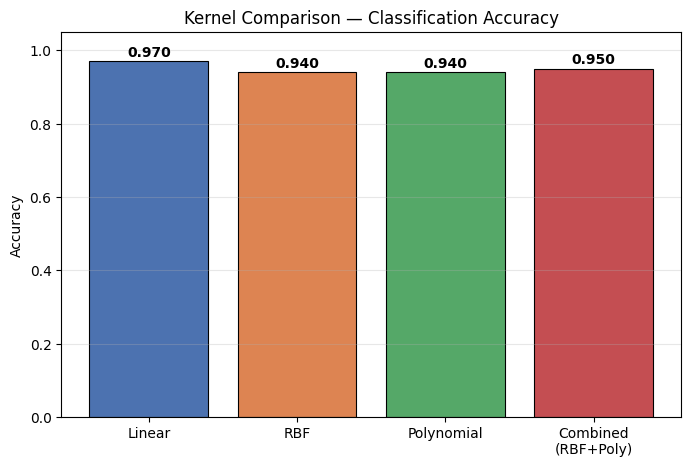

Figure saved to results/kernel_comparison.png


In [58]:
# Visualization: bar chart comparing kernel accuracies
labels = ['Linear', 'RBF', 'Polynomial', 'Combined\n(RBF+Poly)']
accuracies = [
    results['linear']['accuracy'],
    results['rbf']['accuracy'],
    results['poly']['accuracy'],
    combined_acc
]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, accuracies, color=colors, edgecolor='black', linewidth=0.8)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
plt.ylabel('Accuracy')
plt.title('Kernel Comparison — Classification Accuracy')
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.savefig('results/kernel_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to results/kernel_comparison.png")

## Interpretation

---

### How different kernels affect performance

Each kernel function encodes a different notion of similarity between data points. The **linear kernel** works well when classes are linearly separable but may underperform on datasets with nonlinear structure. The **RBF kernel** captures local, nonlinear patterns and generally performs well across diverse datasets. The **polynomial kernel** models feature interactions up to a given degree, which can help or hurt depending on the data's structure.

### Why combining kernels can improve results

By averaging the predicted probabilities from multiple kernel-based SVMs, we simulate the core idea of Multiple Kernel Learning (MKL): different kernels capture complementary aspects of the data, and their combination can outperform any single kernel. This is analogous to the paper's approach of learning a linear combination of base kernels $k = \sum_m d_m k_m$ (Eq 2), where the weights $d_m$ are optimized to maximize classification performance.

### Connection to the paper

The reference paper (Section 2.1) identifies that margin-based MKL methods tend to select only one dominant kernel rather than learning a meaningful combination. The paper's Radius-based Kernel Learning (RKL) addresses this by incorporating the MEB radius into the objective (Section 2.2), encouraging the optimization to balance multiple kernels. Our experiment demonstrates the simpler version of this idea — that combining kernel perspectives can be beneficial — which motivates the need for principled kernel combination methods like RKL.

## Margin–Radius Analysis (Connection to the Paper)

The paper argues that kernel quality should be evaluated using the relationship between the classifier margin and the radius of the dataset in feature space. The theoretical generalization bound (Section 2.2) depends on the product $R^2 \|w\|^2$, where $R$ is the radius of the Minimum Enclosing Ball (MEB) and $w$ is the SVM weight vector. A smaller value of this product indicates better expected generalization.

In this simplified reproduction, we approximate this idea by computing the classifier margin from a linear SVM and an approximate dataset radius from the training data.

In [59]:
# Compute classifier margin from linear SVM
linear_model = SVC(kernel='linear', random_state=42)
linear_model.fit(X_train_scaled, y_train)

w_norm = np.linalg.norm(linear_model.coef_)
margin = 1 / w_norm

print(f"Weight vector norm ||w||: {w_norm:.4f}")
print(f"Classifier margin (1/||w||): {margin:.4f}")

Weight vector norm ||w||: 3.5929
Classifier margin (1/||w||): 0.2783


The SVM margin is computed as $1 / \|w\|$, where $w$ is the classifier weight vector — a larger margin generally indicates better separation between the two classes. In the paper, the classifier margin is one of the two factors influencing the theoretical generalization bound (Section 2.2), the other being the MEB radius $R$. Together, they form the product $R^2 \|w\|^2$ that the paper's RKL method seeks to minimize.

In [60]:
# Compute dataset radius approximation (max distance from mean)
center = np.mean(X_train_scaled, axis=0)
radius = np.max(np.linalg.norm(X_train_scaled - center, axis=1))

radius_squared = radius ** 2
margin_squared = margin ** 2

# Compute margin-radius ratio
ratio = margin_squared / radius_squared

print(f"Margin: {margin:.4f}")
print(f"Radius: {radius:.4f}")
print(f"Margin^2 / Radius^2: {ratio:.6f}")

Margin: 0.2783
Radius: 4.5519
Margin^2 / Radius^2: 0.003739


The dataset radius approximates the spread of the data in feature space. The paper uses the radius of the Minimum Enclosing Ball (MEB) to measure this spread (Section 2.2, Eq 7–8); here we approximate it by computing the maximum Euclidean distance of any training sample from the dataset center. This is a simplified proxy but captures the same intuition — a larger radius means the data occupies a wider region of feature space, which directly affects the generalization bound $R^2 \|w\|^2$.

### Margin–Radius Explanation

The ratio $\text{margin}^2 / R^2$ is a simplified proxy for the generalization bound discussed in the paper (Section 2.2). A **larger ratio** suggests the classifier has a wide margin relative to the data spread, indicating better expected generalization. A **smaller ratio** means the margin is narrow compared to the data's extent, leaving less room for error.

The paper's key insight is that standard margin-based MKL ignores the radius $R$, optimizing only the margin. This can lead to kernels that produce large feature-space radii, inflating $R^2 \|w\|^2$ even when the margin looks good. By incorporating $R$ directly into the objective (Eq 9), the RKL method finds kernel combinations that balance both margin and data spread — exactly what this metric captures in simplified form.

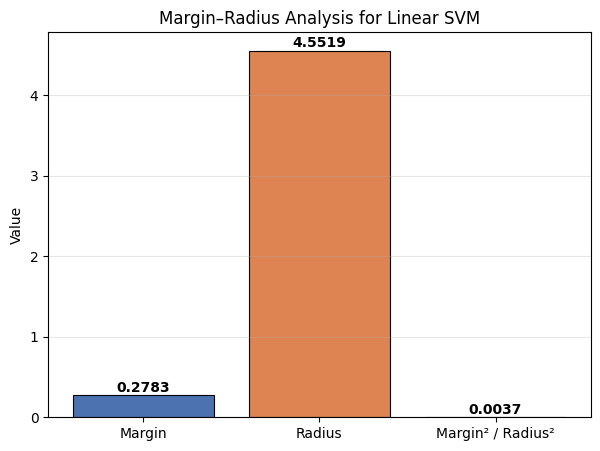

Figure saved to results/margin_radius_analysis.png


In [61]:
# Margin–Radius bar chart
labels_mr = ['Margin', 'Radius', 'Margin² / Radius²']
values_mr = [margin, radius, ratio]
colors_mr = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(7, 5))
bars_mr = ax.bar(labels_mr, values_mr, color=colors_mr, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars_mr, values_mr):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Value')
ax.set_title('Margin–Radius Analysis for Linear SVM')
ax.grid(axis='y', alpha=0.3)
plt.savefig('results/margin_radius_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to results/margin_radius_analysis.png")

In [62]:
import pandas as pd

# Summary table of all kernel experiments
summary = pd.DataFrame({
    'Kernel': ['Linear', 'RBF', 'Polynomial', 'Combined (RBF + Polynomial)'],
    'Accuracy': [
        results['linear']['accuracy'],
        results['rbf']['accuracy'],
        results['poly']['accuracy'],
        combined_acc
    ]
})

summary

,Kernel,Accuracy
0,Linear,0.97
1,RBF,0.94
2,Polynomial,0.94
3,Combined (RBF + Polynomial),0.95


## Summary Interpretation

- **Different kernels produce different classification margins.** The linear kernel finds a hyperplane directly in the input space, yielding one margin, while nonlinear kernels (RBF, polynomial) operate in transformed feature spaces with different geometric properties — resulting in different effective margins and accuracies.
- **Kernel combinations may capture richer feature spaces.** Averaging predictions from RBF and polynomial SVMs combines two complementary views of the data. This simulates the paper's idea of forming a combined kernel $k = \sum_m d_m k_m$ (Eq 2) that spans a richer feature space than any single kernel alone.
- **This motivates kernel learning methods like the one proposed in the paper.** Rather than manually choosing or naively averaging kernels, the paper's RKL method (Section 3.2) learns optimal kernel weights by jointly optimizing classification margin and data radius — producing principled combinations that generalize better than ad-hoc strategies.